# CW targeting and relative orbit elements

This notebook builds the two tools that every proximity-operations plan is made of, on top of the Hill-Clohessy-Wiltshire (HCW) dynamics from `cw_comparison.ipynb`:

1. **Relative orbit elements** — a geometric way to read a relative state: how big is the ellipse, where is its center, how fast does it drift, and where on the ellipse is the deputy.
2. **Two-impulse targeting** — given where the deputy is and where it must be after a fixed time of flight, compute the two burns that do it.
3. **Putting them together** — insertion of the deputy onto a passively safe **2:1 relative ellipse**, verified by integrating the true Hill equations with heyoka.

These are exactly the ingredients of the full rendezvous (parking orbit → phasing → far-range rendezvous → 2:1 ellipse). Two of them will keep growing in later layers: the 2:1 ellipse is the *safety ellipse* of the safety layer, and the delta-v values computed here feed the propellant budget of the end-to-end layer.

Units are metres and seconds throughout. All relative states live in the chief's LVLH frame: $x$ radial, $y$ along-track, $z$ cross-track.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from ios_mission_planner.dynamics.relative.hill import hill_equations_symbolic
from ios_mission_planner.dynamics.relative.cw import cw_state_transition_matrix, cw_targeting
from ios_mission_planner.dynamics.relative.relative_orbit import (
    RelativeOrbit, relative_orbit_from_state, state_from_relative_orbit,
)
from ios_mission_planner.propagation.heyoka_propagator import propagate

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

COL_NUM = "#d62728"
COL_ANA = "#1f77b4"
COL_CHIEF = "#2ca02c"

In [2]:
# Chief: circular LEO at 500 km altitude
mu_earth = 398600.4418        # km^3/s^2
a_chief = 6378.137 + 500.0    # km
n = np.sqrt(mu_earth / a_chief**3)   # rad/s
T = 2 * np.pi / n                     # s

print(f"n = {n:.6e} rad/s")
print(f"T = {T:.1f} s  ({T/60:.2f} min)")

n = 1.106783e-03 rad/s
T = 5677.0 s  (94.62 min)


## Part 1 — Relative orbit elements

Group the terms of the closed-form CW solution by how they behave in time: a constant, a term growing linearly, and terms oscillating at the orbital frequency $n$. The in-plane and out-of-plane motion then read (see also Analytical Mechanics of Space Systems, Ed. 4, page 781):

$$
\begin{aligned}
x(t) &= x_{off} + \rho\cos(nt+\alpha)\\
y(t) &= y_c - \tfrac{3}{2}\,n\,x_{off}\,t - 2\rho\sin(nt+\alpha)\\
z(t) &= \rho_z\cos(nt+\beta)
\end{aligned}
$$

Reading it geometrically:

- The in-plane motion is a **2:1 ellipse**: radial semi-axis $\rho$, along-track semi-axis $2\rho$, traversed once per orbit.
- The ellipse **center** sits at radial offset $x_{off}$ and slides along-track at $-\tfrac32 n x_{off}$. So the *only* source of secular drift is $x_{off}$, i.e. a difference in semi-major axis (energy) between deputy and chief. $x_{off}=0$ means same period, no drift.
- $y_c$ is where the center is along-track at $t=0$, and $\alpha$ is where the deputy is on the ellipse.

From an initial state $(x_0, y_0, z_0, \dot x_0, \dot y_0, \dot z_0)$, with $a = 3x_0 + 2\dot y_0/n$ and $b = \dot x_0/n$ (see also Analytical Mechanics of Space Systems, Ed. 4, page 785):

$$
x_{off} = 4x_0 + \frac{2\dot y_0}{n},\quad
y_c = y_0 - 2b,\quad
\rho = \sqrt{a^2+b^2},\quad
\alpha = \operatorname{atan2}(-b,-a)
$$

and $x_{off}=0 \Leftrightarrow \dot y_0 = -2nx_0$, the drift-free condition already seen in `cw_comparison.ipynb`. The six numbers $(x_{off}, y_c, \rho, \alpha, \rho_z, \beta)$ carry the same information as the six state components, but they are the quantities that mission constraints are written in: size of the ellipse, drift, hold-point offset, phase. That is what `relative_orbit_from_state` and `state_from_relative_orbit` convert between.

Below, two orbits are propagated with heyoka (solid) and compared against the closed-form description above (dashed).

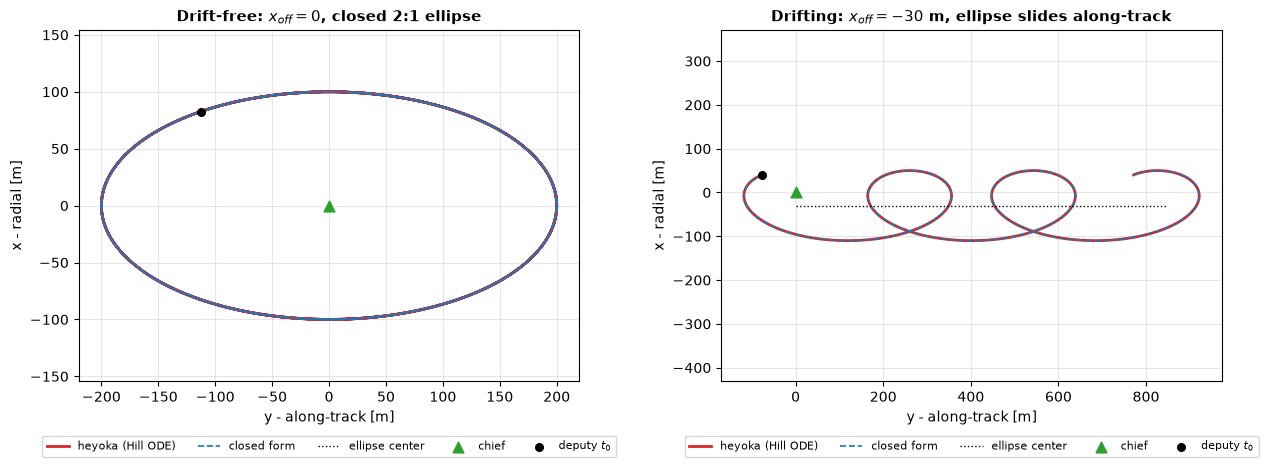

max |heyoka - closed form|, drift-free: 1.79e-12 m
max |heyoka - closed form|, drifting  : 1.02e-12 m
drift rate of the second orbit: 0.0498 m/s = 282.7 m per orbit


In [3]:
def orbit_position(orbit, t, n):
    """Position [x, y, z] from the closed-form relative-orbit description."""
    x = orbit.x_off + orbit.rho * np.cos(n * t + orbit.alpha)
    y = orbit.y_c + orbit.drift_rate(n) * t - 2.0 * orbit.rho * np.sin(n * t + orbit.alpha)
    z = orbit.rho_z * np.cos(n * t + orbit.beta)
    return np.array([x, y, z])


def plot_relative_orbit(ax, orbit, n_periods, title):
    t = np.linspace(0, n_periods * T, 800)
    state0 = state_from_relative_orbit(orbit, n)
    numerical = propagate(hill_equations_symbolic(), state0, t, pars=[n]).y
    analytic = orbit_position(orbit, t, n)

    ax.plot(numerical[1], numerical[0], color=COL_NUM, lw=2, label="heyoka (Hill ODE)")
    ax.plot(analytic[1], analytic[0], color=COL_ANA, lw=1.2, ls="--", label="closed form")
    y_center = orbit.y_c + orbit.drift_rate(n) * t
    ax.plot(y_center, np.full_like(t, orbit.x_off), color="k", lw=1, ls=":", label="ellipse center")
    ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=60, zorder=5, label="chief")
    ax.scatter([numerical[1, 0]], [numerical[0, 0]], color="k", s=30, zorder=5, label="deputy $t_0$")
    ax.set_xlabel("y - along-track [m]")
    ax.set_ylabel("x - radial [m]")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=5)

    return np.max(np.abs(numerical[:3] - analytic))


orbit_free = RelativeOrbit(x_off=0.0, y_c=0.0, rho=100.0, alpha=0.6)
orbit_drift = RelativeOrbit(x_off=-30.0, y_c=0.0, rho=80.0, alpha=0.5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
err_free = plot_relative_orbit(axes[0], orbit_free, 3, "Drift-free: $x_{off}=0$, closed 2:1 ellipse")
err_drift = plot_relative_orbit(axes[1], orbit_drift, 3, "Drifting: $x_{off}=-30$ m, ellipse slides along-track")
plt.tight_layout()
plt.show()

print(f"max |heyoka - closed form|, drift-free: {err_free:.2e} m")
print(f"max |heyoka - closed form|, drifting  : {err_drift:.2e} m")
print(f"drift rate of the second orbit: {orbit_drift.drift_rate(n):.4f} m/s "
      f"= {orbit_drift.drift_rate(n) * T:.1f} m per orbit")

The conversion is invertible: a raw state goes to elements and back without loss. Here for the drifting orbit above.

In [4]:
state_drift = state_from_relative_orbit(orbit_drift, n)
recovered = relative_orbit_from_state(state_drift, n)

print("state (x, y, z, vx, vy, vz):")
print(" ", np.array2string(state_drift, precision=5, suppress_small=True))
print()
print(f"{'element':8s} {'original':>12s} {'recovered':>12s}")
for name in ["x_off", "y_c", "rho", "alpha", "rho_z", "beta"]:
    print(f"{name:8s} {getattr(orbit_drift, name):12.6f} {getattr(recovered, name):12.6f}")

state (x, y, z, vx, vy, vz):
  [ 40.2066  -76.70809   0.       -0.04245  -0.1056   -0.     ]

element      original    recovered
x_off      -30.000000   -30.000000
y_c          0.000000     0.000000
rho         80.000000    80.000000
alpha        0.500000     0.500000
rho_z        0.000000     0.000000
beta         0.000000     0.000000


## Part 2 — Two-impulse targeting

**The problem.** The deputy is at $(\mathbf r_0, \mathbf v_0^-)$ and must be at $(\mathbf r_f, \mathbf v_f)$ after a time of flight $t$. With impulsive burns the trajectory in between is a free CW coast, so the whole problem is one linear-algebra step on the state transition matrix. Split the STM into $3\times3$ blocks:

$$
\begin{bmatrix}\mathbf r(t)\\ \mathbf v(t)\end{bmatrix}
=
\begin{bmatrix}\Phi_{rr} & \Phi_{rv}\\ \Phi_{vr} & \Phi_{vv}\end{bmatrix}
\begin{bmatrix}\mathbf r_0\\ \mathbf v_0^+\end{bmatrix}
$$

where $\mathbf v_0^+ = \mathbf v_0^- + \Delta\mathbf v_1$ is the velocity right after the first burn. The position equation $\mathbf r_f = \Phi_{rr}\mathbf r_0 + \Phi_{rv}\mathbf v_0^+$ gives

$$
\mathbf v_0^+ = \Phi_{rv}^{-1}\left(\mathbf r_f - \Phi_{rr}\mathbf r_0\right),
\qquad \Delta\mathbf v_1 = \mathbf v_0^+ - \mathbf v_0^-
$$

Plugging $\mathbf v_0^+$ into the velocity equation gives the velocity the deputy actually has on arrival, $\mathbf v(t)^- = \Phi_{vr}\mathbf r_0 + \Phi_{vv}\mathbf v_0^+$, and the second burn closes the gap to the desired velocity:

$$
\Delta\mathbf v_2 = \mathbf v_f - \mathbf v(t)^-
$$

**When it breaks.** Everything hinges on inverting $\Phi_{rv}$. In-plane its determinant is

$$
\det\Phi_{rv}^{\,\text{in-plane}} = \frac{8 - 8\cos nt - 3\,nt\,\sin nt}{n^2}
$$

which vanishes at a full orbit and at other special times of flight. At those times $\Phi_{rv}$ loses rank and one of two things happens: either the target position is unreachable by a free coast and the required $\Delta v$ diverges, or the target happens to be reachable in infinitely many ways and the solver silently returns just one of them (not necessarily the cheapest). Which one depends on the target, so a singular time of flight is always a red flag. (The out-of-plane block, $\sin(nt)/n$, vanishes at half orbits, but that only matters if the target has an out-of-plane component.)

The example: a **V-bar hop** from a hold point at $y=-1000$ m to a hold point at $y=-200$ m, both at rest. Let's see how the cost depends on the time of flight.

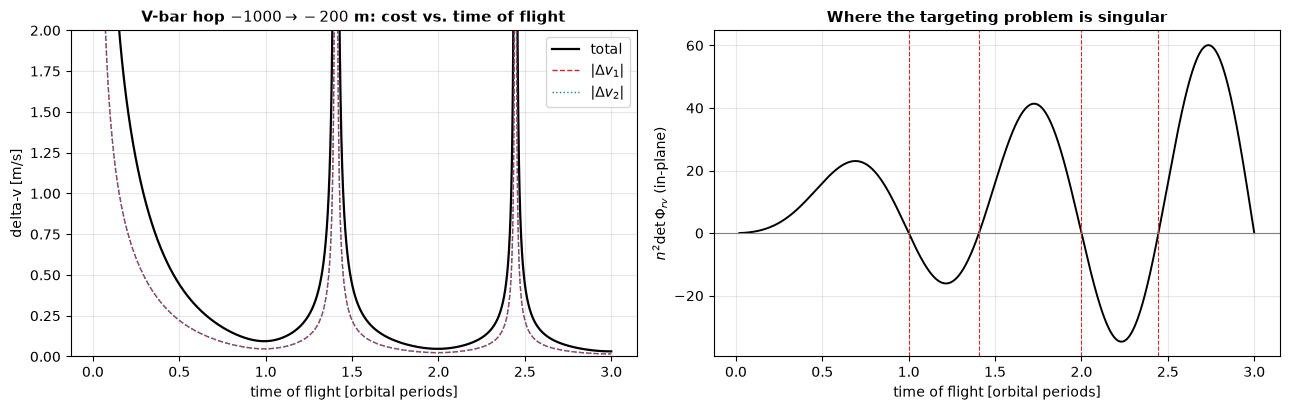

singular times of flight [orbital periods]: [1.    1.406 1.999 2.445]

  time of flight     |dv1|     |dv2|     total   [m/s]
         0.25 P    0.6022    0.6022    1.2044
         0.50 P    0.2214    0.2214    0.4427
         0.75 P    0.0894    0.0894    0.1789
         1.25 P    0.1272    0.1272    0.2545
         1.75 P    0.0483    0.0483    0.0966
         2.50 P    0.2214    0.2214    0.4427


In [5]:
r0 = np.array([0.0, -1000.0, 0.0])
v0 = np.zeros(3)
rf = np.array([0.0, -200.0, 0.0])
vf = np.zeros(3)


def dv_vs_tof(r0, v0, rf, vf, t_over_p):
    """|dv1|, |dv2|, total for each time of flight (in orbital periods). NaN where singular."""
    out = np.full((len(t_over_p), 3), np.nan)
    for i, f in enumerate(t_over_p):
        try:
            dv1, dv2 = cw_targeting(r0, v0, rf, vf, f * T, n)
        except np.linalg.LinAlgError:
            continue
        out[i, :2] = np.linalg.norm(dv1), np.linalg.norm(dv2)
    out[:, 2] = out[:, 0] + out[:, 1]
    return out


f = np.linspace(0.02, 3.0, 3000)
dv = dv_vs_tof(r0, v0, rf, vf, f)

u = 2 * np.pi * f
det_in_plane = (8 - 8 * np.cos(u) - 3 * u * np.sin(u)) / n**2
singular_at = f[:-1][np.sign(det_in_plane[:-1]) != np.sign(det_in_plane[1:])]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(f, dv[:, 2], color="k", lw=1.6, label="total")
axes[0].plot(f, dv[:, 0], color=COL_NUM, lw=1, ls="--", label="$|\\Delta v_1|$")
axes[0].plot(f, dv[:, 1], color=COL_ANA, lw=1, ls=":", label="$|\\Delta v_2|$")
axes[0].set_ylim(0, 2.0)
axes[0].set_xlabel("time of flight [orbital periods]")
axes[0].set_ylabel("delta-v [m/s]")
axes[0].set_title("V-bar hop $-1000\\to-200$ m: cost vs. time of flight")
axes[0].legend()

axes[1].plot(f, det_in_plane * n**2, color="k", lw=1.4)
axes[1].axhline(0, color="gray", lw=0.8)
for s in singular_at:
    axes[1].axvline(s, color=COL_NUM, lw=0.8, ls="--")
axes[1].set_xlabel("time of flight [orbital periods]")
axes[1].set_ylabel("$n^2 \\det\\Phi_{rv}$ (in-plane)")
axes[1].set_title("Where the targeting problem is singular")

plt.tight_layout()
plt.show()

print("singular times of flight [orbital periods]:", np.round(singular_at, 3))
print()
print(f"{'time of flight':>16s} {'|dv1|':>9s} {'|dv2|':>9s} {'total':>9s}   [m/s]")
for f_sel in [0.25, 0.5, 0.75, 1.25, 1.75, 2.5]:
    d1, d2 = dv_vs_tof(r0, v0, rf, vf, np.array([f_sel]))[0, :2]
    print(f"{f_sel:13.2f} P {d1:9.4f} {d2:9.4f} {d1 + d2:9.4f}")

Three things worth noticing:

- **Fast hops are expensive, and the cost is not monotonic.** For short times of flight the cost grows steeply (you must push hard and brake hard). Beyond that it oscillates: cheap windows (around 0.75 and 1.75 orbits in the table) sit between the singular spikes, and a longer flight is not automatically a cheaper one (2.5 orbits costs more than 0.75). The time of flight is a design trade-off between propellant and mission time, not a detail.
- **Singular times.** The dashed lines on the right mark where $\det\Phi_{rv}=0$: $1.000$, $1.406$, $1.999$, $2.445$ orbits. At $1.406$ and $2.445$ the cost diverges. At exactly $1$ and $2$ orbits it does not, because this hop is purely along-track and the target is still consistent (a free coast returns to $x=0$ after a full orbit), but the solution there is not unique, so those points should not be trusted blindly.
- The two burns have the same magnitude here because the problem is symmetric (rest to rest). It will not be so for the ellipse insertion below.

The helper `fly` below applies a list of impulses and coasts with heyoka, so the result is checked by the **true Hill equations**, independently of the STM used to compute the burns.

time of flight : 71.0 min (0.75 orbits)
dv1 = [-0.07999 -0.04    -0.     ] m/s   |dv1| = 0.08944 m/s
dv2 = [-0.07999  0.04     0.     ] m/s   |dv2| = 0.08944 m/s
total dv = 0.17887 m/s

arrival position error (heyoka vs. target): 1.14e-13 m
drift during the following orbit at the new hold point: 1.82e-12 m


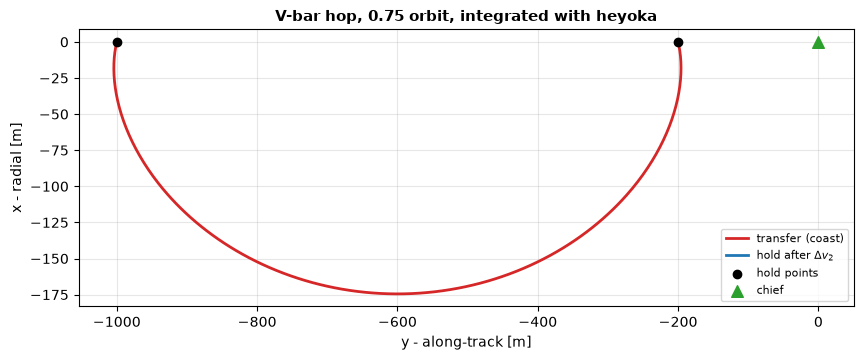

In [6]:
def fly(state0, plan, n, pts=400):
    """
    Integrate a sequence of (impulse, coast duration) pairs with heyoka.

    Each impulse dv is added to the velocity at the start of its leg, then the
    deputy coasts for the given duration. Returns time, states [n_samples, 6],
    and the state right after each impulse.
    """
    state = np.array(state0, dtype=float)
    t_start = 0.0
    times, states, after_burn = [], [], []

    for dv, duration in plan:
        state[3:] += dv
        after_burn.append(state.copy())

        t_eval = np.linspace(0.0, duration, pts)
        leg = propagate(hill_equations_symbolic(), state, t_eval, pars=[n])

        times.append(t_start + t_eval)
        states.append(leg.y.T)
        state = leg.y[:, -1].copy()
        t_start += duration

    return np.concatenate(times), np.vstack(states), after_burn


T_hop = 0.75 * T
dv1, dv2 = cw_targeting(r0, v0, rf, vf, T_hop, n)

t, y, after_burn = fly(np.concatenate([r0, v0]), [(dv1, T_hop), (dv2, T)], n)
pts = 400   # samples per leg, as in fly()

print(f"time of flight : {T_hop / 60:.1f} min ({T_hop / T:.2f} orbits)")
print(f"dv1 = {np.array2string(dv1, precision=5, suppress_small=True)} m/s   |dv1| = {np.linalg.norm(dv1):.5f} m/s")
print(f"dv2 = {np.array2string(dv2, precision=5, suppress_small=True)} m/s   |dv2| = {np.linalg.norm(dv2):.5f} m/s")
print(f"total dv = {np.linalg.norm(dv1) + np.linalg.norm(dv2):.5f} m/s")
print()
print(f"arrival position error (heyoka vs. target): {np.linalg.norm(y[pts - 1, :3] - rf):.2e} m")
print(f"drift during the following orbit at the new hold point: {np.linalg.norm(y[-1, :3] - rf):.2e} m")

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(y[:pts, 1], y[:pts, 0], color=COL_NUM, lw=2, label="transfer (coast)")
ax.plot(y[pts:, 1], y[pts:, 0], color=COL_ANA, lw=2, label="hold after $\\Delta v_2$")
ax.scatter([r0[1], rf[1]], [r0[0], rf[0]], color="k", zorder=5, label="hold points")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
ax.set_xlabel("y - along-track [m]")
ax.set_ylabel("x - radial [m]")
ax.set_title("V-bar hop, 0.75 orbit, integrated with heyoka")
ax.legend(fontsize=8)
plt.show()

The transfer bows out radially and comes back: a rest-to-rest V-bar hop is never a straight line in the CW frame, because along-track motion couples to radial motion through the Coriolis-like terms $2n\dot y$ and $-2n\dot x$.

## Part 3 — Insertion onto the 2:1 ellipse

Now the target is not a point but a *state*: a point on a drift-free 2:1 ellipse, with the ellipse velocity. If the arrival state satisfies $\dot y = -2nx$ and has $x_{off}=0$, then after the second burn the deputy stays on the ellipse for free, forever (within the linear model). This is the passively safe parking orbit: no burn is needed to hold it, and if the deputy stops responding it keeps circling the chief instead of drifting into it.

Choose an ellipse with $\rho = 100$ m (radial semi-axis, so 200 m along-track) centered on the chief, and arrive at the point $x=0,\ y=-2\rho$, which corresponds to phase $\alpha = \pi/2$ at arrival. The targeting is the same `cw_targeting` call as before, only with a non-zero target velocity. Notice in the results that $\Delta v_1$ comes out identical to the V-bar hop: the first burn depends only on the positions $(\mathbf r_0, \mathbf r_f)$ and the time of flight, so changing the arrival *velocity* only changes $\Delta v_2$.

target arrival state (x, y, z, vx, vy, vz):
  [   0.      -200.         0.        -0.11068   -0.        -0.     ]
drift-free check  vy + 2 n x = 1.5e-33


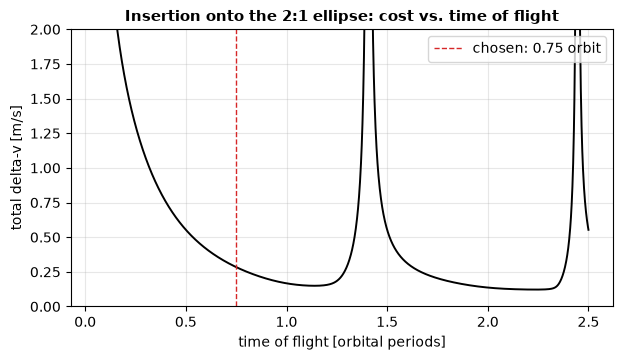

In [7]:
rho_f = 100.0
target_orbit = RelativeOrbit(x_off=0.0, y_c=0.0, rho=rho_f, alpha=np.pi / 2)   # phase at the arrival instant
state_arrival = state_from_relative_orbit(target_orbit, n)

print("target arrival state (x, y, z, vx, vy, vz):")
print(" ", np.array2string(state_arrival, precision=5, suppress_small=True))
print(f"drift-free check  vy + 2 n x = {state_arrival[4] + 2 * n * state_arrival[0]:.1e}")

r0 = np.array([0.0, -1000.0, 0.0])
v0 = np.zeros(3)

f = np.linspace(0.05, 2.5, 2000)
dv_ins = np.full(len(f), np.nan)
for i, fi in enumerate(f):
    try:
        d1, d2 = cw_targeting(r0, v0, state_arrival[:3], state_arrival[3:], fi * T, n)
        dv_ins[i] = np.linalg.norm(d1) + np.linalg.norm(d2)
    except np.linalg.LinAlgError:
        pass

T_ins = 0.75 * T
dv1, dv2 = cw_targeting(r0, v0, state_arrival[:3], state_arrival[3:], T_ins, n)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(f, dv_ins, color="k", lw=1.4)
ax.axvline(T_ins / T, color=COL_NUM, ls="--", lw=1, label="chosen: 0.75 orbit")
ax.set_ylim(0, 2.0)
ax.set_xlabel("time of flight [orbital periods]")
ax.set_ylabel("total delta-v [m/s]")
ax.set_title("Insertion onto the 2:1 ellipse: cost vs. time of flight")
ax.legend()
plt.show()

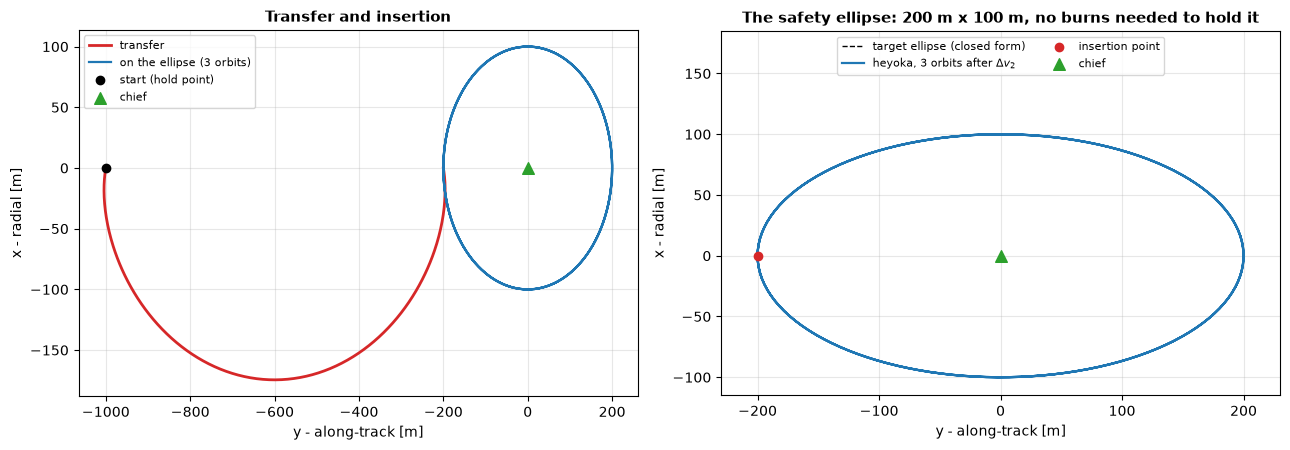

dv1 = [-0.07999 -0.04    -0.     ] m/s   |dv1| = 0.08944 m/s
dv2 = [-0.19067  0.04    -0.     ] m/s   |dv2| = 0.19482 m/s
total dv = 0.28426 m/s

relative orbit right after the second burn:
  x_off = 1.82e-13 m   (0 = no drift)
  drift = -3.02e-16 m/s
  rho   = 100.0000 m   (target 100.0)
  y_c   = 1.42e-13 m

arrival position error (heyoka vs. target) : 1.14e-13 m
position error after 3 full orbits on the ellipse: 3.56e-12 m


In [8]:
n_ellipse_orbits = 3
t, y, after_burn = fly(np.concatenate([r0, v0]), [(dv1, T_ins), (dv2, n_ellipse_orbits * T)], n)
pts = 400

phi = np.linspace(0, 2 * np.pi, 400)
ellipse_x = target_orbit.rho * np.cos(phi)
ellipse_y = -2 * target_orbit.rho * np.sin(phi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.plot(y[:pts, 1], y[:pts, 0], color=COL_NUM, lw=2, label="transfer")
ax.plot(y[pts:, 1], y[pts:, 0], color=COL_ANA, lw=1.6, label="on the ellipse (3 orbits)")
ax.scatter([r0[1]], [r0[0]], color="k", zorder=5, label="start (hold point)")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
ax.set_xlabel("y - along-track [m]")
ax.set_ylabel("x - radial [m]")
ax.set_title("Transfer and insertion")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(ellipse_y, ellipse_x, color="k", lw=1, ls="--", label="target ellipse (closed form)")
ax.plot(y[pts:, 1], y[pts:, 0], color=COL_ANA, lw=1.6, label="heyoka, 3 orbits after $\\Delta v_2$")
ax.scatter([state_arrival[1]], [state_arrival[0]], color=COL_NUM, zorder=5, label="insertion point")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
ax.set_xlabel("y - along-track [m]")
ax.set_ylabel("x - radial [m]")
ax.set_title("The safety ellipse: 200 m x 100 m, no burns needed to hold it")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-230, 230)
ax.set_ylim(-115, 185)
ax.legend(fontsize=8, loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

after = relative_orbit_from_state(after_burn[1], n)
print(f"dv1 = {np.array2string(dv1, precision=5, suppress_small=True)} m/s   |dv1| = {np.linalg.norm(dv1):.5f} m/s")
print(f"dv2 = {np.array2string(dv2, precision=5, suppress_small=True)} m/s   |dv2| = {np.linalg.norm(dv2):.5f} m/s")
print(f"total dv = {np.linalg.norm(dv1) + np.linalg.norm(dv2):.5f} m/s")
print()
print("relative orbit right after the second burn:")
print(f"  x_off = {after.x_off:.2e} m   (0 = no drift)")
print(f"  drift = {after.drift_rate(n):.2e} m/s")
print(f"  rho   = {after.rho:.4f} m   (target {rho_f})")
print(f"  y_c   = {after.y_c:.2e} m")
print()
print(f"arrival position error (heyoka vs. target) : {np.linalg.norm(y[pts - 1, :3] - state_arrival[:3]):.2e} m")
print(f"position error after {n_ellipse_orbits} full orbits on the ellipse: "
      f"{np.linalg.norm(y[-1, :3] - after_burn[1][:3]):.2e} m")

## Summary

- **Relative orbit elements** turn a CW state into six numbers with direct physical meaning. The 2:1 ellipse, its size $\rho$, its phase $\alpha$, its center $y_c$, and the single quantity that creates drift, $x_{off}$.
- **Two-impulse targeting** is one linear solve on the STM blocks. The cost depends strongly on the time of flight and diverges at singular times, so the time of flight is something to choose, not assume.
- **Insertion onto the 2:1 ellipse** is just targeting to an ellipse state. The result was cross-checked by integrating the real Hill equations with heyoka: the arrival error is at the level of numerical noise, and the deputy closes the ellipse orbit after orbit with no further burns.

**What comes next.** The rendezvous notebook chains these pieces: a phasing leg to close the along-track gap from the parking orbit, a far-range targeting burn pair into the neighbourhood of the chief, and the insertion onto the 2:1 ellipse shown here. Downstream layers reuse it directly: the ellipse geometry ($\rho$, $y_c$, $x_{off}$) is the input to keep-out and passive-safety analysis, and every $\Delta v$ computed here is a line item in the propellant budget.